In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from flow import sample_images
from utils import load_checkpoint
from torchdiffeq import odeint
import time
from torch import optim
from unet_v2 import UnetV2


/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
torch.manual_seed(159753)
np.random.seed(159753)

torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)


In [3]:

%%capture
im_size = 128
problem = "eit-circles"
ckp_index = 12750

def checkpoint_path(x):
    return f'problems/conv-multiflow-v1/{problem}/checkpoints/{x}/ckp_{ckp_index}.tar'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conv_levels = 4
conv_0_model = UnetV2(ch=32).to(device)
conv_1_model = UnetV2(ch=32).to(device)
conv_2_model = UnetV2(ch=32).to(device)
conv_3_model = UnetV2(ch=32).to(device)

_, _, conv_0_model , _, _, _= load_checkpoint(model=conv_0_model, path=checkpoint_path('no_conv'))
_, _, conv_1_model, _, _, _= load_checkpoint(model=conv_1_model, path=checkpoint_path('conv_1'))
_, _, conv_2_model, _, _, _= load_checkpoint(model=conv_2_model, path=checkpoint_path('conv_2'))
_, _, conv_3_model, _, _, _= load_checkpoint(model=conv_3_model, path=checkpoint_path('conv_3'))
conv_0_model.eval()
conv_1_model.eval()
conv_2_model.eval()
conv_3_model.eval()
models = [conv_0_model, conv_1_model, conv_2_model, conv_3_model]

In [4]:
from typing import Dict, List, Optional

import torch.nn as nn


def inverse_loss_fn(x, y, media, lambda_reg=1e-2):
    """
    Loss function with Tikhonov (L2) regularization.

    Args:
        x: predicted values
        y: target values
        lambda_reg: regularization parameter
    """
    data_loss = torch.sum((x - y) ** 2)
    # Tikhonov regularization term (L2 norm of x)
    reg_loss = lambda_reg * torch.norm(media, p=2) ** 2

    # Total loss
    total_loss = data_loss + reg_loss

    return total_loss


def ode_integrate(
    ode_func: nn.Module,
    init_x: torch.Tensor,
    ode_opts: Dict = {},
    t_eps: float = 0,
    init_t: float = 0.0,
    final_t: float = 1.0,
    t_arr: Optional[List[float]] = None,
    num_steps: int = 5,
    intermediate_points: bool = False,
) -> torch.Tensor:
    if t_arr is None:
        t = torch.linspace(init_t - t_eps, final_t, num_steps).to(init_x.device)
    else:
        t = torch.tensor(t_arr, dtype=torch.float32, device=init_x.device)

    ode_opts = {
        "atol": 1e-5,
        "rtol": 1e-5,
        "method": "rk4",  # "dopri5", "rk4", "euler", "adams", "bdf"
        **ode_opts,
    }

    z = odeint(
        func=lambda t, x: ode_func(x, t.expand(x.shape[0])), y0=init_x, t=t, **ode_opts
    )

    if not intermediate_points:
        return z[-1]
    return z


/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


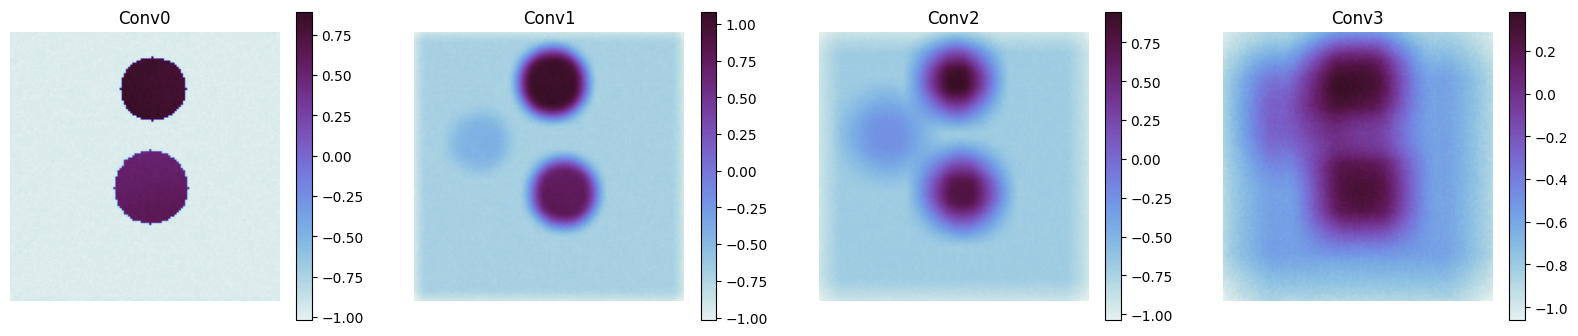

In [5]:
# test each model out 
x = torch.randn(1, 1, im_size, im_size).to(device)
outputs = []
for model in models:
    with torch.no_grad():
        output = ode_integrate(model, x, num_steps=10)
        outputs.append(output)
# plot 
plt.figure(figsize=(20,4))
titles = ['Conv0', 'Conv1', 'Conv2', 'Conv3']
for i, output in enumerate(outputs):
    plt.subplot(1, 4, i + 1)
    plt.imshow(output.squeeze().cpu(), cmap=cmocean.cm.dense)
    plt.colorbar()
    plt.title(titles[i])
    plt.axis('off')
plt.show()



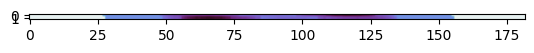

In [8]:
from transforms.radon import radon_transform
test_data = torch.load(f"data/{problem}-dataset-{im_size}.pt")["test"]
idx = 70
gt = test_data[idx].to(device).unsqueeze(0)
radon_gt = radon_transform(gt, N =2)
plt.imshow(radon_gt.squeeze().cpu(), cmap=cmocean.cm.dense)

In [9]:
# getting normalization constants
conv_data_train = torch.load(f"data/{problem}-conv-dataset-128.pt")['train']
normalization_constants = {}
# todo: rewrite this mess
conv_map = {
    'no_conv': 'Conv0',
    'kernel_size11_sigma4': 'Conv1',
    'kernel_size21_sigma12': 'Conv2',
    'kernel_size45_sigma25': 'Conv3'
}
for i, conv in enumerate(['no_conv', 
             'kernel_size11_sigma4',
             'kernel_size21_sigma12', 
             'kernel_size45_sigma25'
             ]):
    conv_data = conv_data_train[conv]
    train_min, train_max = (torch.min(conv_data), torch.max(conv_data))
    normalization_constants[conv_map[conv]] = {"train_min": train_min, "train_max": train_max}

In [ ]:
nu = [5, 15, 20, 30]
target_cost = 1e-3
time_limit = 500
lr = [0.2, 0.7, 0.7, 0.5]
x1_trajectory = []
dtn_trajectory = []
x0_trajectory = []
init_x = torch.randn((1, 1, im_size, im_size), device=device, dtype=torch.float32)
init_x.requires_grad = True
y = radon_gt 
max_iter = 10
# optimizer = optim.LBFGS([init_x], max_iter=max_iter, lr=lr[0], history_size=10)
optimizer = torch.optim.SGD([init_x], lr=lr[0], nesterov=False, momentum=0.0)
# optimizer = optim.Adam([init_x], lr=lr[0], betas=(0.9, 0.99), eps=1e-8, weight_decay=0.01)

start_time = time.time()
# add metrics to tqdm
models.reverse()
for i, model in enumerate(models):
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr[i]
    train_max = normalization_constants[titles[models.index(model)]]["train_max"]
    train_min = normalization_constants[titles[models.index(model)]]["train_min"]
    for step in range(nu[i]):
        def closure():
            global loss
            global x1
            global dtn_trajectory
            optimizer.zero_grad()

            ### solve for x1
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                x1 = ode_integrate(ode_func=model, init_x=init_x, num_steps=5)
            # unnormalize x1
            x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min

            # degraded_x1 = H(x1)
            degraded_x1 = radon_transform(x1, N=2)
            dtn_trajectory.append(degraded_x1.detach().cpu().numpy())

            cost = inverse_loss_fn(degraded_x1, y, x1, lambda_reg=0)
            loss = cost

            loss.backward()
            return loss

        optimizer.step(closure)

        x1_trajectory.append(x1.detach().cpu().numpy())
        x0_trajectory.append(init_x.detach().cpu().numpy())

        # print metrics

        elapsed = time.time() - start_time

        elapsed = elapsed / 60
        print(f"[Step {step}] Loss {loss.item()}" + f"| time: {elapsed} mins")

        if target_cost is not None:
            if loss.item() <= target_cost:
                print(f"reached cost of {loss.item()}")
                break

    with torch.no_grad():
        x1 = ode_integrate(model, init_x)
        x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
    x1_trajectory.append(x1.detach().cpu().numpy())
    x0_trajectory.append(init_x.detach().cpu().numpy())


torch.Size([1, 1, 2, 182])
[Step 0] Loss 543145.125| time: 0.005329251289367676 mins
torch.Size([1, 1, 2, 182])
[Step 1] Loss nan| time: 0.010511970520019532 mins
torch.Size([1, 1, 2, 182])
[Step 2] Loss nan| time: 0.015674463907877603 mins
torch.Size([1, 1, 2, 182])
[Step 3] Loss nan| time: 0.02086320718129476 mins
torch.Size([1, 1, 2, 182])
[Step 4] Loss nan| time: 0.026074556509653728 mins
torch.Size([1, 1, 2, 182])
[Step 0] Loss nan| time: 0.032870086034139 mins
torch.Size([1, 1, 2, 182])
[Step 1] Loss nan| time: 0.03804794947306315 mins
torch.Size([1, 1, 2, 182])
[Step 2] Loss nan| time: 0.04324177106221517 mins
torch.Size([1, 1, 2, 182])
[Step 3] Loss nan| time: 0.048420274257659913 mins
torch.Size([1, 1, 2, 182])
[Step 4] Loss nan| time: 0.05361520846684774 mins
torch.Size([1, 1, 2, 182])
[Step 5] Loss nan| time: 0.05879739920298258 mins
torch.Size([1, 1, 2, 182])
[Step 6] Loss nan| time: 0.06397891044616699 mins
torch.Size([1, 1, 2, 182])
[Step 7] Loss nan| time: 0.069164089361

KeyboardInterrupt: 

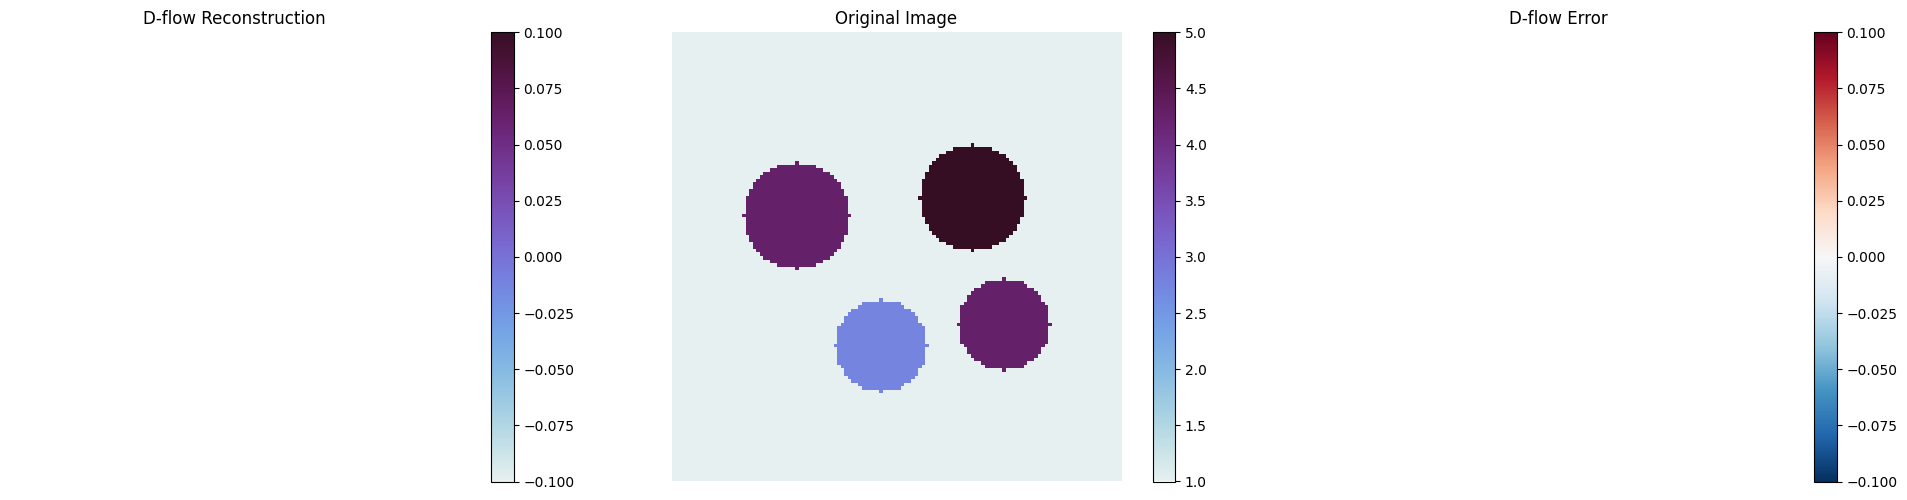

D-flow Results
MSE: nan
MAE: nan
PSNR: nan dB
Rel. L2 Error: nan


In [11]:
import warnings

# Suppress warnings from transforms
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(divide="ignore", invalid="ignore")

# plot error and final result
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Reconstructed image (D-flow)
im1 = axes[0].imshow(x1.squeeze().detach().cpu().numpy(), cmap=cmocean.cm.dense)
axes[0].set_title("D-flow Reconstruction")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0])


# Original image
im3 = axes[1].imshow(gt.squeeze().cpu().numpy(), cmap=cmocean.cm.dense)
axes[1].set_title("Original Image")
axes[1].axis("off")
plt.colorbar(im3, ax=axes[1])

# Error/difference (D-flow vs Original)
error = x1.squeeze().detach().cpu().numpy() - gt.squeeze().cpu().numpy()
im4 = axes[2].imshow(
    error, cmap="RdBu_r", vmin=-np.abs(error).max(), vmax=np.abs(error).max()
)
axes[2].set_title("D-flow Error")
axes[2].axis("off")
plt.colorbar(im4, ax=axes[2])

plt.tight_layout()
plt.show()

# Print comparison metrics
mse_dflow = np.mean(error**2)
mae_dflow = np.mean(np.abs(error))
psnr_dflow = 20 * np.log10(np.max(gt.squeeze().cpu().numpy()) / np.sqrt(mse_dflow))

print("D-flow Results")
print(f"MSE: {mse_dflow:.6f}")
print(f"MAE: {mae_dflow:.6f}")
print(f"PSNR: {psnr_dflow:.2f} dB")
print(
    f"Rel. L2 Error: {np.linalg.norm(error) / np.linalg.norm(gt.squeeze().cpu().numpy()):.4f}"
)


In [12]:
import matplotlib.animation as animation
from IPython.display import HTML

# Create animation of x0 trajectory
fig, ax = plt.subplots(figsize=(8, 8))


def animate(frame):
    ax.clear()
    img = dtn_trajectory[frame].squeeze()
    im = ax.imshow(img, cmap=cmocean.cm.dense, vmin=img.min(), vmax=img.max())
    ax.set_title(f"x0 Trajectory- Step {frame}", fontsize=14)
    ax.axis("off")
    return [im]


# Sample every 10th frame to make animation smoother and smaller
frame_indices = list(range(0, len(dtn_trajectory), max(1, len(dtn_trajectory) // 50)))
if len(frame_indices) > 100:  # Limit to 100 frames max
    frame_indices = frame_indices[:: len(frame_indices) // 100]

# Create animation
anim = animation.FuncAnimation(
    fig, animate, frames=frame_indices, interval=200, blit=False, repeat=True
)

plt.close(fig)  # Close the figure to prevent blank canvas display

# Convert to HTML5 video for inline playback
html_anim = HTML(anim.to_jshtml())
html_anim

In [13]:
# Create side-by-side comparison animation
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

gt_img = gt.squeeze().cpu().numpy()


def animate_comparison(frame):
    # Clear all axes
    ax1.clear()
    ax2.clear()
    ax3.clear()

    # Current reconstruction
    current_img = x1_trajectory[frame].squeeze()

    # Plot reconstruction
    im1 = ax1.imshow(
        current_img, cmap=cmocean.cm.dense, vmin=gt_img.min(), vmax=gt_img.max()
    )
    ax1.set_title(f"Reconstruction - Step {frame}", fontsize=12)
    ax1.axis("off")

    # Plot ground truth
    im2 = ax2.imshow(
        gt_img, cmap=cmocean.cm.dense, vmin=gt_img.min(), vmax=gt_img.max()
    )
    ax2.set_title("Ground Truth", fontsize=12)
    ax2.axis("off")

    # Plot difference
    diff = current_img - gt_img
    im3 = ax3.imshow(
        diff, cmap="RdBu_r", vmin=-np.abs(diff).max(), vmax=np.abs(diff).max()
    )
    ax3.set_title(f"Difference", fontsize=12)
    ax3.axis("off")

    return [im1, im2, im3]


# Use same frame sampling as before
anim_comparison = animation.FuncAnimation(
    fig, animate_comparison, frames=frame_indices, interval=300, blit=False, repeat=True
)

plt.close(fig)  # Close the figure to prevent blank canvas display

# Convert to HTML5 video for inline playback
html_comparison = HTML(anim_comparison.to_jshtml())
html_comparison